# Классификация текстов с RNN

In [80]:
import os
import glob
import random
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

### Функции для отображения результатов

In [2]:
def evaluate_model(y_true, y_pred, title, average='macro'):
    print(f"\n{title}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average=average), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average=average), 4))
    print("F1-score :", round(f1_score(y_true, y_pred, average=average), 4))
    print("\nОтчёт по классам:\n", classification_report(y_true, y_pred))


In [3]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок {title}')
    plt.show()


## Считывание данных

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pariza/bbc-news-summary")

print("Path to dataset files:", path)

100%|██████████| 8.91M/8.91M [00:00<00:00, 87.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2


In [5]:
articles_folders_paths = sorted(glob.glob(path+'/BBC News Summary/News Articles/*'))
summaries_folders_paths = sorted(glob.glob(path+'/BBC News Summary/Summaries/*'))


In [6]:
def get_data(folder_paths):
  rows = []

  for folder in folder_paths:
    category = folder.split('/')[-1]
    texts = sorted(glob.glob(folder + '/*'))

    for filepath in texts:
      with open(filepath, 'r', encoding="latin-1") as f:
        content = f.read().strip()
        rows.append([filepath, category, content])

  df = pd.DataFrame(rows, columns=['filename', 'category', 'news'])
  return df


articles_df = get_data(articles_folders_paths)
summaries_df = get_data(summaries_folders_paths)

In [7]:
articles_df.head()

,filename,category,news
0,/root/.cache/kagglehub/datasets/pariza/bbc-new...,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,/root/.cache/kagglehub/datasets/pariza/bbc-new...,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,/root/.cache/kagglehub/datasets/pariza/bbc-new...,business,Yukos unit buyer faces loan claim\n\nThe owner...
3,/root/.cache/kagglehub/datasets/pariza/bbc-new...,business,High fuel prices hit BA's profits\n\nBritish A...
4,/root/.cache/kagglehub/datasets/pariza/bbc-new...,business,Pernod takeover talk lifts Domecq\n\nShares in...


In [8]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2225 non-null   object
 1   category  2225 non-null   object
 2   news      2225 non-null   object
dtypes: object(3)
memory usage: 52.3+ KB


In [9]:
articles_df['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


## Обработка текста

In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer


lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = []
    for word in words:
        # Сначала пробуем как глагол
        lemma_v = lemmatizer.lemmatize(word, pos='v')
        # Если не изменилось — значит, это не глагол (или уже лемма)
        if lemma_v != word:
            lemmatized.append(lemma_v)
        else:
            # Иначе пробуем как существительное (по умолчанию)
            lemmatized.append(lemmatizer.lemmatize(word))
    return ' '.join(lemmatized)

def clear_text(texts):
  cleared_texts = texts.copy()

  # нижний регистр
  cleared_texts = cleared_texts.str.lower()

  # HTML-сущности
  cleared_texts = cleared_texts.str.replace(r'&[^;\s]+;', '', regex=True)

  # ссылки
  cleared_texts = cleared_texts.str.replace(r'http\S+|www\S+', '', regex=True)

  # цифры
  cleared_texts = cleared_texts.str.replace(r'\d+', '', regex=True)

  # Удаляем всё, кроме букв и пробелов (оставляем только a-z и пробелы)
  cleared_texts = cleared_texts.str.replace(r'[^a-z\s]', ' ', regex=True)


  stop_words = set(stopwords.words('english'))

  # Разбиваем на слова, удаляем стоп-слова, собираем обратно
  cleared_texts = cleared_texts.apply(
      lambda text: ' '.join([word for word in text.split() if word not in stop_words])
  )

  # лемматизация
  cleared_texts = cleared_texts.apply(lemmatize_text)

  return cleared_texts

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [11]:
articles_df['news_cleared'] = clear_text(articles_df['news'])
summaries_df['news_cleared'] = clear_text(summaries_df['news'])

In [12]:
le = LabelEncoder()

articles_df['category'] = le.fit_transform(articles_df['category'])
summaries_df['category'] = le.transform(summaries_df['category'])


In [13]:
# все ли лейблы совпадают по индексам?
(articles_df['category'] == summaries_df['category']).all()

np.True_

## Делим на train и test

In [14]:
X_articles = articles_df['news_cleared']
X_summaries = summaries_df['news_cleared']

y = articles_df[['category']]

In [15]:
idx_train, idx_test = train_test_split(
    np.arange(len(X_articles)),
    test_size=0.2,
    random_state=42,
    stratify=y,
)

idx_train2, idx_valid = train_test_split(
    idx_train,
    test_size=0.1,
    random_state=42,
    stratify=y.iloc[idx_train]
)

X_train_a = X_articles.iloc[idx_train2]
X_valid_a = X_articles.iloc[idx_valid]
X_test_a  = X_articles.iloc[idx_test]

X_train_s = X_summaries.iloc[idx_train2]
X_valid_s = X_summaries.iloc[idx_valid]
X_test_s  = X_summaries.iloc[idx_test]

y_train = y.iloc[idx_train2]
y_valid = y.iloc[idx_valid]
y_test    = y.iloc[idx_test]

## Baseline: TF-IDF + RF

### Обучение

In [ ]:
vectorizer_a = TfidfVectorizer(max_features=5000)
X_train_a_vec = vectorizer_a.fit_transform(X_train_a)
X_test_a_vec = vectorizer_a.transform(X_test_a)

vectorizer_s = TfidfVectorizer(max_features=5000)
X_train_s_vec = vectorizer_s.fit_transform(X_train_s)
X_test_s_vec = vectorizer_s.transform(X_test_s)


In [ ]:
def make_random_search(tree_clf, X_train_vec, y_train, param_dist, label=''):
  random_search = RandomizedSearchCV(
      estimator=tree_clf,
      param_distributions=param_dist,
      n_iter=50,
      cv=5,
      scoring='f1_macro',
      random_state=42,
      n_jobs=-1
  )

  random_search.fit(X_train_vec, y_train)
  print(f'Лучшие параметры {label}:', random_search.best_params_)

  best_tree = random_search.best_estimator_
  return best_tree

In [ ]:
tree_a_clf = RandomForestClassifier(random_state=42)
tree_s_clf = RandomForestClassifier(random_state=42)

param_dist = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_leaf_nodes': randint(5, 50),
    'criterion': ['gini', 'entropy', 'log_loss']
}

best_tree_a = make_random_search(tree_a_clf, X_train_a_vec, y_train.values.ravel(), param_dist, label='articles')
best_tree_s = make_random_search(tree_s_clf, X_train_s_vec, y_train.values.ravel(), param_dist, label='summaries')

y_pred_tree_a = best_tree_a.predict(X_test_a_vec)
y_pred_tree_s = best_tree_s.predict(X_test_s_vec)


Лучшие параметры articles: {'criterion': 'log_loss', 'max_depth': 18, 'max_leaf_nodes': 41, 'min_samples_leaf': 1, 'min_samples_split': 18}
Лучшие параметры summaries: {'criterion': 'log_loss', 'max_depth': 18, 'max_leaf_nodes': 41, 'min_samples_leaf': 1, 'min_samples_split': 18}


### Оценка и результаты Random Forest


Модель TF-IDF + Random Forest на articles 

Accuracy : 0.9596
Precision: 0.9631
Recall   : 0.9584
F1-score : 0.9603

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.91      0.96      0.93       102
entertainment       1.00      0.96      0.98        77
     politics       0.96      0.90      0.93        84
        sport       0.97      0.99      0.98       102
         tech       0.97      0.97      0.97        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445



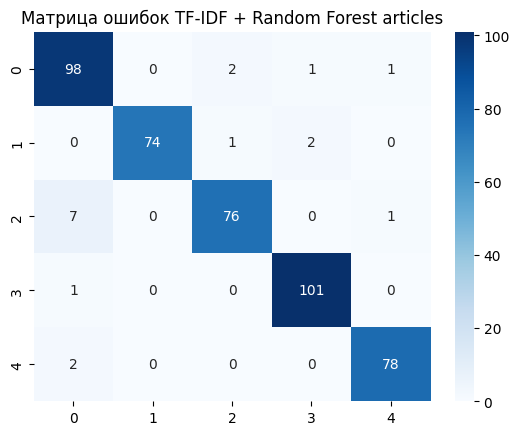

-------------------------------------------------------

Модель TF-IDF + Random Forest на summaries 

Accuracy : 0.9281
Precision: 0.9379
Recall   : 0.9224
F1-score : 0.9277

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.84      0.96      0.89       102
entertainment       1.00      0.84      0.92        77
     politics       0.94      0.92      0.93        84
        sport       0.95      0.99      0.97       102
         tech       0.96      0.90      0.93        80

     accuracy                           0.93       445
    macro avg       0.94      0.92      0.93       445
 weighted avg       0.93      0.93      0.93       445



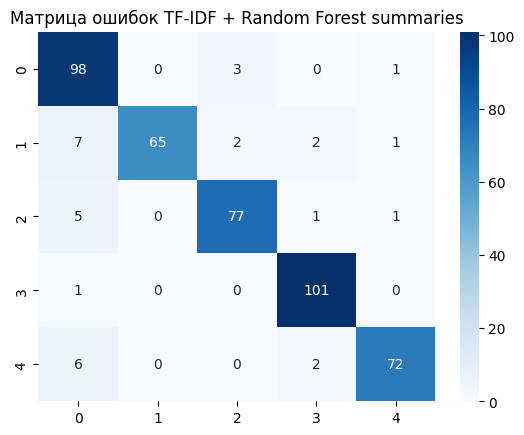

In [ ]:
# по дефолту метрики оцениваются с macro
evaluate_model(le.inverse_transform(y_test.values.ravel()), le.inverse_transform(y_pred_tree_a), "Модель TF-IDF + Random Forest на articles \n")
plot_confusion_matrix(y_test, y_pred_tree_a, "TF-IDF + Random Forest articles")

print('-'*55)

evaluate_model(le.inverse_transform(y_test.values.ravel()), le.inverse_transform(y_pred_tree_s), "Модель TF-IDF + Random Forest на summaries \n")
plot_confusion_matrix(y_test, y_pred_tree_s, "TF-IDF + Random Forest summaries")

## RNN



### nltk токенайзер

In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [17]:
def nltk_tokenizer(text):
  return word_tokenize(text.lower())

all_tokens = [t for text in X_train_a for t in nltk_tokenizer(text)]
counter = Counter(all_tokens)
vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common())}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

In [18]:
def tokenize_and_index(text):
  tokens = [vocab.get(t, vocab["<unk>"]) for t in nltk_tokenizer(text)]
  return tokens

### TextDataset


In [19]:
class TextDataset(Dataset):
  def __init__(self, texts, labels, tokenizer):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts.iloc[idx]
    label = self.labels.iloc[idx]

    tokens = self.tokenizer(text)

    return tokens, label

In [20]:
def collate_fn(batch):
  texts, labels = zip(*batch)

  max_len = max(len(t) for t in texts)
  padded = [t + [vocab["<pad>"]] * (max_len - len(t)) for t in texts]

  labels = torch.tensor([l.item() for l in labels], dtype=torch.int64)

  return torch.tensor(padded, dtype=torch.long), labels

In [21]:
#articles
train_a_dataset = TextDataset(X_train_a, y_train, tokenize_and_index)
valid_a_dataset = TextDataset(X_valid_a, y_valid, tokenize_and_index)
test_a_dataset = TextDataset(X_test_a, y_test, tokenize_and_index)

train_a_loader = DataLoader(train_a_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
valid_a_loader = DataLoader(valid_a_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_a_loader = DataLoader(test_a_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

#summaries
train_s_dataset = TextDataset(X_train_s, y_train, tokenize_and_index)
valid_s_dataset = TextDataset(X_valid_s, y_valid, tokenize_and_index)
test_s_dataset = TextDataset(X_test_s, y_test, tokenize_and_index)

train_s_loader = DataLoader(train_s_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
valid_s_loader = DataLoader(valid_s_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_s_loader = DataLoader(test_s_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


### реализация RNN

In [23]:
class RNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, dropout, hidden_dim, output_dim):
        super().__init__()

        self.d = dropout
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.rnn(embedded)
        predictions = None

        if self.d > 0:
            hidden = self.dropout(hidden[-1,:,:])
            predictions = self.fc(hidden)
        else:
            predictions = self.fc(hidden.squeeze(0))

        return predictions

In [24]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [25]:
num_classes = y_train['category'].nunique()

INPUT_DIM = len(vocab)
EMB_DIM = 128
HID_DIM = 256
OUTPUT_DIM = num_classes
DROPOUT = 0.37

model_a = RNN(INPUT_DIM, EMB_DIM, DROPOUT, HID_DIM, OUTPUT_DIM).to(device)
model_s = RNN(INPUT_DIM, EMB_DIM, DROPOUT, HID_DIM, OUTPUT_DIM).to(device)

### Функции для обучения и оценки модели

In [26]:
def evaluate_nn_model(model, test_loader, device):
  model.eval()
  all_predictions = []
  all_labels = []

  with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch
        texts = texts.to(device)
        labels = labels.to(device)

        outputs = model(texts)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

  return all_predictions, all_labels


def train_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0

  for texts, labels in loader:
    texts = texts.to(device)
    labels = labels.to(device)

    _pred = model(texts)
    loss = criterion(_pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for texts, labels in loader:
      texts = texts.to(device)
      labels = labels.to(device)

      pred = model(texts)
      loss = criterion(pred, labels)

      total_loss += loss.item()

      preds = pred.argmax(dim=1)
      correct += (preds == labels).sum().item()
      total += len(labels)

  accuracy = correct / total
  return total_loss / len(loader), accuracy


def train_model(model, train_loader, valid_loader, device, title, num_epochs = 100):
  print(f'Обученаем {title} \n')

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

  best_model_state = None
  best_valid_loss = float("inf")

  for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      patience_counter = 0
      best_model_state = deepcopy(model.state_dict())

  model.load_state_dict(best_model_state)
  model.eval()

  return model


### Обучение RNN моделей

In [27]:
model_a = train_model(model_a, train_a_loader, valid_a_loader, device, 'RNN на article')

Обученаем RNN на article 

Epoch 1/100
Train Loss: 1.6249
Valid Loss: 1.5781 | Valid Acc: 0.2640
Epoch 2/100
Train Loss: 1.5651
Valid Loss: 1.5491 | Valid Acc: 0.3034
Epoch 3/100
Train Loss: 1.5097
Valid Loss: 1.5227 | Valid Acc: 0.3090
Epoch 4/100
Train Loss: 1.4472
Valid Loss: 1.4975 | Valid Acc: 0.3315
Epoch 5/100
Train Loss: 1.3938
Valid Loss: 1.4684 | Valid Acc: 0.3820
Epoch 6/100
Train Loss: 1.3260
Valid Loss: 1.4243 | Valid Acc: 0.4213
Epoch 7/100
Train Loss: 1.2257
Valid Loss: 1.3044 | Valid Acc: 0.4607
Epoch 8/100
Train Loss: 1.0838
Valid Loss: 1.2249 | Valid Acc: 0.5112
Epoch 9/100
Train Loss: 0.9968
Valid Loss: 1.1674 | Valid Acc: 0.5393
Epoch 10/100
Train Loss: 0.9300
Valid Loss: 1.3140 | Valid Acc: 0.4775
Epoch 11/100
Train Loss: 0.9126
Valid Loss: 1.1623 | Valid Acc: 0.5562
Epoch 12/100
Train Loss: 0.7320
Valid Loss: 1.0270 | Valid Acc: 0.5955
Epoch 13/100
Train Loss: 0.6685
Valid Loss: 0.9322 | Valid Acc: 0.6404
Epoch 14/100
Train Loss: 0.5964
Valid Loss: 0.9373 | Valid 

In [28]:
model_s = train_model(model_s, train_s_loader, valid_s_loader, device, 'RNN на summaries')

Обученаем RNN на summaries 

Epoch 1/100
Train Loss: 1.6036
Valid Loss: 1.5842 | Valid Acc: 0.2191
Epoch 2/100
Train Loss: 1.5499
Valid Loss: 1.5643 | Valid Acc: 0.2472
Epoch 3/100
Train Loss: 1.4962
Valid Loss: 1.5471 | Valid Acc: 0.2809
Epoch 4/100
Train Loss: 1.4549
Valid Loss: 1.5314 | Valid Acc: 0.3146
Epoch 5/100
Train Loss: 1.4079
Valid Loss: 1.5171 | Valid Acc: 0.3315
Epoch 6/100
Train Loss: 1.3574
Valid Loss: 1.4956 | Valid Acc: 0.3371
Epoch 7/100
Train Loss: 1.2944
Valid Loss: 1.4006 | Valid Acc: 0.4382
Epoch 8/100
Train Loss: 1.1764
Valid Loss: 1.3506 | Valid Acc: 0.4326
Epoch 9/100
Train Loss: 1.0724
Valid Loss: 1.3281 | Valid Acc: 0.4438
Epoch 10/100
Train Loss: 0.9789
Valid Loss: 1.2453 | Valid Acc: 0.5337
Epoch 11/100
Train Loss: 0.9061
Valid Loss: 1.2112 | Valid Acc: 0.5056
Epoch 12/100
Train Loss: 0.8987
Valid Loss: 1.1521 | Valid Acc: 0.5562
Epoch 13/100
Train Loss: 0.7976
Valid Loss: 1.1387 | Valid Acc: 0.5506
Epoch 14/100
Train Loss: 0.7401
Valid Loss: 1.1677 | Vali

### Оценка и результаты RNN


оценка RNN на articles 

Accuracy : 0.8247
Precision: 0.8292
Recall   : 0.8232
F1-score : 0.8226

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.85      0.73      0.78       102
entertainment       0.79      0.86      0.82        77
     politics       0.87      0.80      0.83        84
        sport       0.79      0.96      0.87       102
         tech       0.85      0.78      0.81        80

     accuracy                           0.82       445
    macro avg       0.83      0.82      0.82       445
 weighted avg       0.83      0.82      0.82       445



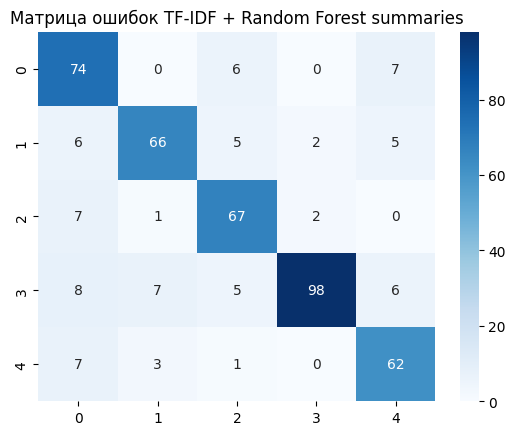


оценка RNN на summaries 

Accuracy : 0.7708
Precision: 0.776
Recall   : 0.7683
F1-score : 0.7691

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.73      0.76      0.75       102
entertainment       0.76      0.74      0.75        77
     politics       0.82      0.63      0.71        84
        sport       0.75      0.84      0.80       102
         tech       0.82      0.86      0.84        80

     accuracy                           0.77       445
    macro avg       0.78      0.77      0.77       445
 weighted avg       0.77      0.77      0.77       445



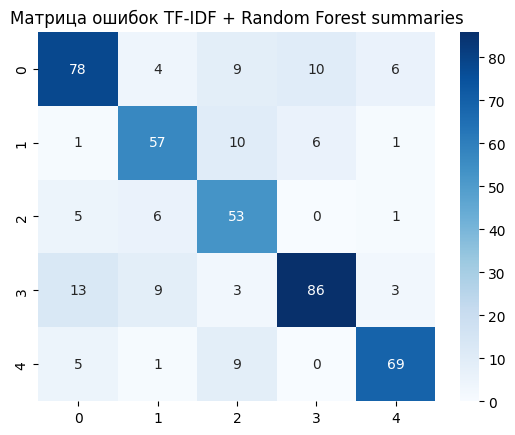

In [29]:
predictions, true_labels = evaluate_nn_model(model_a, test_a_loader, device)
y_pred_a, y_true_a = le.inverse_transform(true_labels), le.inverse_transform(predictions)
evaluate_model(y_pred_a, y_true_a, 'оценка RNN на articles \n')
plot_confusion_matrix(y_true_a, y_pred_a, "TF-IDF + Random Forest summaries")

predictions, true_labels = evaluate_nn_model(model_s, test_s_loader, device)
y_pred_s, y_true_s = le.inverse_transform(true_labels), le.inverse_transform(predictions)
evaluate_model(y_pred_s, y_true_s, 'оценка RNN на summaries \n')
plot_confusion_matrix(y_true_s, y_pred_s, "TF-IDF + Random Forest summaries")

## Расширенные возможности RNN

### Функция для выделения топ k значимых слов в тексте

In [35]:
def extract_keywords(model, text, top_k=5):
    model.eval()

    tokens = nltk_tokenizer(text)
    indexed = torch.tensor([vocab.get(t, vocab["<unk>"]) for t in tokens]).unsqueeze(0).to(device)

    with torch.no_grad():
        embedded = model.embedding(indexed)
        outputs, hidden = model.rnn(embedded)

        forward_final = hidden[0]
        backward_final = hidden[1]
        final_state = torch.cat([forward_final, backward_final], dim=1).squeeze(0)

        outputs = outputs.squeeze(0)
        similarities = F.cosine_similarity(outputs, final_state.unsqueeze(0))

    sorted_indices = similarities.argsort(descending=True).cpu().tolist()

    unique_keywords = []
    for idx in sorted_indices:
        tok = tokens[idx]
        if tok not in unique_keywords:
            unique_keywords.append(tok)
        if len(unique_keywords) == top_k:
            break

    return unique_keywords


In [38]:
text = X_articles.iloc[0]
keywords = extract_keywords(model_a, text, top_k=5)
print("Ключевые слова:", keywords)


Ключевые слова: ['ad', 'pay', 'company', 'say', 'deal']


In [49]:
le.inverse_transform(y.iloc[0])

array(['business'], dtype=object)

In [50]:
text

'ad sale boost time warner profit quarterly profit u medium giant timewarner jump bn three month december year earlier firm one biggest investor google benefit sale high speed internet connection higher advert sale timewarner say fourth quarter sale rise bn bn profit buoy one gain offset profit dip warner bros less user aol time warner say friday own search engine google internet business aol mix fortune lose subscriber fourth quarter profit lower precede three quarter however company say aol underlie profit exceptional item rise back stronger internet advertise revenue hop increase subscriber offer online service free timewarner internet customer try sign aol exist customer high speed broadband timewarner also restate result follow probe u security exchange commission sec close conclude time warner fourth quarter profit slightly better analyst expectation film division saw profit slump help box office flop alexander catwoman sharp contrast year earlier third final film lord ring trilo

### Создадим новые данные на основе 5 значимых слов

In [60]:
X_articles_short = X_articles.copy()
X_summaries_short = X_summaries.copy()

X_articles_short.rename({'news_cleared' : 'news_cleared_short'}, inplace=True)
X_summaries_short.rename({'news_cleared' : 'news_cleared_short'}, inplace=True)

In [73]:
def fill_with_top_k_words(model, X_text, out_df):

  for i, text in enumerate(X_text):
      kw = extract_keywords(model, text, top_k=5)
      out_df.iloc[i] = ' '.join(kw)

  return out_df


In [74]:
X_articles_short = fill_with_top_k_words(model_a, X_articles, X_articles_short)

X_summaries_short = fill_with_top_k_words(model_s, X_summaries, X_summaries_short)

In [75]:
X_articles_short.head()

,news_cleared
0,ad pay company say deal
1,dollar spend speech euro government
2,yukos credit pay asset rosneft
3,high fuel impact year quarter
4,pernod lift talk refuse share


In [77]:
X_train_keywords_a = X_articles_short.iloc[idx_train2]
X_test_keywords_a  = X_articles_short.iloc[idx_test]

X_train_keywords_s = X_summaries.iloc[idx_train2]
X_test_keywords_s  = X_summaries.iloc[idx_test]

### TF-IDF + Logigistic Regression

In [78]:
vectorizer_a = TfidfVectorizer(max_features=5000)
X_train_a_vec = vectorizer_a.fit_transform(X_train_keywords_a)
X_test_a_vec = vectorizer_a.transform(X_test_keywords_a)

vectorizer_s = TfidfVectorizer(max_features=5000)
X_train_s_vec = vectorizer_s.fit_transform(X_train_keywords_s)
X_test_s_vec = vectorizer_s.transform(X_test_keywords_s)


In [83]:
model_reg_a = LogisticRegression(max_iter=1000)
model_reg_s = LogisticRegression(max_iter=1000)

model_reg_a.fit(X_train_a_vec, y_train.values.ravel())
model_reg_s.fit(X_train_s_vec, y_train.values.ravel())

y_pred_reg_a = model_reg_a.predict(X_test_a_vec)
y_pred_reg_s = model_reg_s.predict(X_test_s_vec)


Модель TF-IDF + Logistic Regression 5 keywords на articles 

Accuracy : 0.7573
Precision: 0.798
Recall   : 0.7493
F1-score : 0.7606

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.76      0.73      0.74       102
entertainment       0.86      0.66      0.75        77
     politics       0.94      0.70      0.80        84
        sport       0.62      0.93      0.74       102
         tech       0.82      0.72      0.77        80

     accuracy                           0.76       445
    macro avg       0.80      0.75      0.76       445
 weighted avg       0.79      0.76      0.76       445



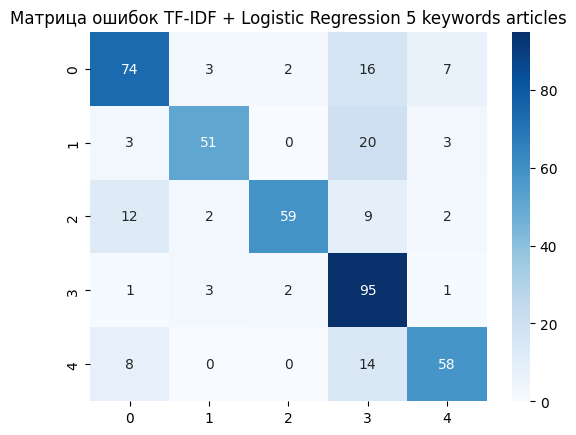

-------------------------------------------------------

Модель TF-IDF + Logistic Regression 5 keywords на summaries 

Accuracy : 0.9708
Precision: 0.9699
Recall   : 0.9705
F1-score : 0.9701

Отчёт по классам:
                precision    recall  f1-score   support

     business       0.98      0.96      0.97       102
entertainment       0.97      0.97      0.97        77
     politics       0.93      0.95      0.94        84
        sport       0.99      0.99      0.99       102
         tech       0.97      0.97      0.97        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



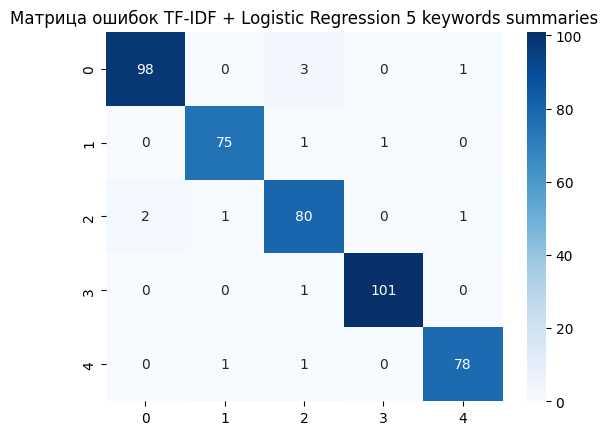

In [85]:
# по дефолту метрики оцениваются с macro
evaluate_model(le.inverse_transform(y_test.values.ravel()), le.inverse_transform(y_pred_reg_a), "Модель TF-IDF + Logistic Regression 5 keywords на articles \n")
plot_confusion_matrix(y_test, y_pred_reg_a, "TF-IDF + Logistic Regression 5 keywords articles")

print('-'*55)

evaluate_model(le.inverse_transform(y_test.values.ravel()), le.inverse_transform(y_pred_reg_s), "Модель TF-IDF + Logistic Regression 5 keywords на summaries \n")
plot_confusion_matrix(y_test, y_pred_reg_s, "TF-IDF + Logistic Regression 5 keywords summaries")